In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from pathlib import Path
import pandas as pd

# Project folders
BASE_DIR = Path.cwd().parent
DATASET_DIR = BASE_DIR / "datasets"

print("Dataset folder:")
print(DATASET_DIR)

# Load datasets
water_df = pd.read_csv(
    DATASET_DIR / "water_consumption_forecasting.csv"
)

flood_df = pd.read_csv(
    DATASET_DIR / "flood_risk_dataset_india.csv"
)

rain_df = pd.read_csv(
    DATASET_DIR / "Sub_Division_IMD_2017.csv"
)

# Check the exact soil filename in your datasets folder
print("\nFiles available:")
for file in DATASET_DIR.glob("*.csv"):
    print(file.name)

Dataset folder:
C:\Users\kvaad\OneDrive\Desktop\ML water-intelligence\datasets

Files available:
flood_risk_dataset_india.csv
sm_Telangana_2020.csv
Sub_Division_IMD_2017.csv
water_consumption_forecasting.csv


In [3]:
# Find the soil moisture dataset automatically
soil_files = [
    file for file in DATASET_DIR.glob("*.csv")
    if "soil" in file.name.lower()
    or "sm_" in file.name.lower()
]

print("Possible soil dataset files:")
for file in soil_files:
    print(file.name)

# Load the first matching soil dataset
soil_file = soil_files[0]
soil_df = pd.read_csv(soil_file)

print("\nSoil dataset loaded:")
print(soil_file.name)

Possible soil dataset files:
sm_Telangana_2020.csv

Soil dataset loaded:
sm_Telangana_2020.csv


In [4]:
datasets = {
    "Water Consumption": water_df,
    "Flood Risk": flood_df,
    "Rainfall": rain_df,
    "Soil Moisture": soil_df
}

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    print("\nColumn names:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    print("\nData types:")
    print(df.dtypes)


Water Consumption
Rows: 900
Columns: 3

Column names:
['region', 'date', 'consumption_liters']

Missing values:
region                0
date                  0
consumption_liters    0
dtype: int64

Duplicate rows: 0

Data types:
region                    str
date                      str
consumption_liters    float64
dtype: object

Flood Risk
Rows: 10000
Columns: 14

Column names:
['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density', 'Infrastructure', 'Historical Floods', 'Flood Occurred']

Missing values:
Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floo

In [5]:
# Create output folders

CLEANED_DIR = BASE_DIR / "data" / "cleaned"
FEATURE_DIR = BASE_DIR / "data" / "features"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"

CLEANED_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders ready!")

Output folders ready!


In [6]:
# WATER CONSUMPTION CLEANING

water_clean = water_df.copy()

# Convert date
water_clean["date"] = pd.to_datetime(
    water_clean["date"],
    errors="coerce"
)

# Remove rows where essential values are missing
water_clean = water_clean.dropna(
    subset=["date", "consumption_liters"]
)

# Remove exact duplicates
water_clean = water_clean.drop_duplicates()

# Sort chronologically
water_clean = water_clean.sort_values("date")

# Save cleaned dataset
water_clean.to_csv(
    CLEANED_DIR / "water_consumption_cleaned.csv",
    index=False
)

print("Water dataset cleaned!")
print("Rows:", len(water_clean))
print("Missing values:", water_clean.isnull().sum().sum())

Water dataset cleaned!
Rows: 900
Missing values: 0


In [9]:
# FLOOD RISK CLEANING

flood_clean = flood_df.copy()

# Remove exact duplicate rows
flood_clean = flood_clean.drop_duplicates()

# Identify numeric and categorical columns
numeric_cols = flood_clean.select_dtypes(
    include=np.number
).columns

categorical_cols = flood_clean.select_dtypes(
    include=["object", "string"]
).columns

# Fill numeric missing values using median
for col in numeric_cols:
    if flood_clean[col].isnull().any():
        flood_clean[col] = flood_clean[col].fillna(
            flood_clean[col].median()
        )

# Fill categorical missing values using mode
for col in categorical_cols:
    if flood_clean[col].isnull().any():
        mode_value = flood_clean[col].mode()

        if not mode_value.empty:
            flood_clean[col] = flood_clean[col].fillna(
                mode_value.iloc[0]
            )

# Save
flood_clean.to_csv(
    CLEANED_DIR / "flood_risk_cleaned.csv",
    index=False
)

print("Flood dataset cleaned!")
print("Rows:", len(flood_clean))
print("Columns:", len(flood_clean.columns))
print("Missing values:", flood_clean.isnull().sum().sum())

Flood dataset cleaned!
Rows: 10000
Columns: 14
Missing values: 0


In [10]:
# RAINFALL CLEANING

rain_clean = rain_df.copy()

# Remove exact duplicate rows
rain_clean = rain_clean.drop_duplicates()

# Convert YEAR to numeric
if "YEAR" in rain_clean.columns:
    rain_clean["YEAR"] = pd.to_numeric(
        rain_clean["YEAR"],
        errors="coerce"
    )

# Fill missing numeric values with median
numeric_cols = rain_clean.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    if rain_clean[col].isnull().any():
        rain_clean[col] = rain_clean[col].fillna(
            rain_clean[col].median()
        )

# Save cleaned dataset
rain_clean.to_csv(
    CLEANED_DIR / "rainfall_cleaned.csv",
    index=False
)

print("Rainfall dataset cleaned!")
print("Rows:", len(rain_clean))
print("Columns:", len(rain_clean.columns))
print("Missing values:", rain_clean.isnull().sum().sum())
print("Duplicates:", rain_clean.duplicated().sum())

Rainfall dataset cleaned!
Rows: 4188
Columns: 19
Missing values: 0
Duplicates: 0


In [13]:
# ============================================================
# SOIL MOISTURE DATA CLEANING
# ============================================================

soil_clean = soil_df.copy()

# ------------------------------------------------------------
# 1. Convert Date column
# ------------------------------------------------------------

soil_clean["Date"] = pd.to_datetime(
    soil_clean["Date"],
    errors="coerce"
)

# Remove rows with invalid dates
soil_clean = soil_clean.dropna(subset=["Date"])

# ------------------------------------------------------------
# 2. Remove exact duplicate rows
# ------------------------------------------------------------

soil_clean = soil_clean.drop_duplicates()

# ------------------------------------------------------------
# 3. Automatically identify soil moisture target column
# ------------------------------------------------------------

soil_target = None

for col in soil_clean.columns:
    if "soilmoisture" in col.lower().replace(" ", ""):
        soil_target = col
        break

if soil_target is None:
    raise ValueError(
        "Soil moisture target column was not found. "
        "Check the column names."
    )

print("Target column detected:", soil_target)

# ------------------------------------------------------------
# 4. Sort data
# ------------------------------------------------------------

if "DistrictName" in soil_clean.columns:
    soil_clean = soil_clean.sort_values(
        ["DistrictName", "Date"]
    )
else:
    soil_clean = soil_clean.sort_values("Date")

# ------------------------------------------------------------
# 5. Fill missing soil moisture values
# ------------------------------------------------------------

if "DistrictName" in soil_clean.columns:

    soil_clean[soil_target] = (
        soil_clean
        .groupby("DistrictName")[soil_target]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit_direction="both"
            )
        )
    )

else:

    soil_clean[soil_target] = (
        soil_clean[soil_target]
        .interpolate(
            method="linear",
            limit_direction="both"
        )
    )

# ------------------------------------------------------------
# 6. Fill any remaining missing target values with median
# ------------------------------------------------------------

if soil_clean[soil_target].isnull().any():

    soil_clean[soil_target] = soil_clean[soil_target].fillna(
        soil_clean[soil_target].median()
    )

# ------------------------------------------------------------
# 7. Fill remaining numerical missing values
# ------------------------------------------------------------

numeric_cols = soil_clean.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    if soil_clean[col].isnull().any():

        soil_clean[col] = soil_clean[col].fillna(
            soil_clean[col].median()
        )

# ------------------------------------------------------------
# 8. Fill categorical missing values
# ------------------------------------------------------------

categorical_cols = soil_clean.select_dtypes(
    include=["object", "string"]
).columns

for col in categorical_cols:

    if soil_clean[col].isnull().any():

        mode_value = soil_clean[col].mode()

        if not mode_value.empty:
            soil_clean[col] = soil_clean[col].fillna(
                mode_value.iloc[0]
            )

# ------------------------------------------------------------
# 9. Save cleaned dataset
# ------------------------------------------------------------

soil_clean.to_csv(
    CLEANED_DIR / "soil_moisture_cleaned.csv",
    index=False
)

# ------------------------------------------------------------
# 10. Final verification
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SOIL MOISTURE CLEANING COMPLETED")
print("=" * 60)

print("Rows:", len(soil_clean))
print("Columns:", len(soil_clean.columns))
print("Target:", soil_target)
print("Remaining missing values:",
      soil_clean.isnull().sum().sum())
print("Duplicates:",
      soil_clean.duplicated().sum())

print("\nSaved to:")
print(CLEANED_DIR / "soil_moisture_cleaned.csv")

Target column detected: Average Soilmoisture Level (at 15cm)

SOIL MOISTURE CLEANING COMPLETED
Rows: 2480
Columns: 7
Target: Average Soilmoisture Level (at 15cm)
Remaining missing values: 0
Duplicates: 0

Saved to:
C:\Users\kvaad\OneDrive\Desktop\ML water-intelligence\data\cleaned\soil_moisture_cleaned.csv


In [14]:
# ============================================================
# FINAL CLEANING VERIFICATION
# ============================================================

cleaned_datasets = {
    "Water Consumption": water_clean,
    "Flood Risk": flood_clean,
    "Rainfall": rain_clean,
    "Soil Moisture": soil_clean
}

print("=" * 70)
print("FINAL DATA CLEANING SUMMARY")
print("=" * 70)

for name, df in cleaned_datasets.items():

    print("\n" + name)
    print("-" * 50)

    print("Rows       :", df.shape[0])
    print("Columns    :", df.shape[1])
    print("Missing    :", df.isnull().sum().sum())
    print("Duplicates :", df.duplicated().sum())

FINAL DATA CLEANING SUMMARY

Water Consumption
--------------------------------------------------
Rows       : 900
Columns    : 3
Missing    : 0
Duplicates : 0

Flood Risk
--------------------------------------------------
Rows       : 10000
Columns    : 14
Missing    : 0
Duplicates : 0

Rainfall
--------------------------------------------------
Rows       : 4188
Columns    : 19
Missing    : 0
Duplicates : 0

Soil Moisture
--------------------------------------------------
Rows       : 2480
Columns    : 7
Missing    : 0
Duplicates : 0


In [15]:
# ============================================================
# EDA 1 — WATER CONSUMPTION
# ============================================================

print("=" * 70)
print("WATER CONSUMPTION — BASIC STATISTICS")
print("=" * 70)

print("\nDataset shape:")
print(water_clean.shape)

print("\nStatistical summary:")
print(water_clean.describe())

print("\nRegions:")
print(water_clean["region"].unique())

print("\nDate range:")
print("Start:", water_clean["date"].min())
print("End  :", water_clean["date"].max())

WATER CONSUMPTION — BASIC STATISTICS

Dataset shape:
(900, 3)

Statistical summary:
                      date  consumption_liters
count                  900          900.000000
mean   2023-03-31 12:00:00        12753.758211
min    2023-01-01 00:00:00         5004.090000
25%    2023-02-14 18:00:00         9187.247500
50%    2023-03-31 12:00:00        13045.510000
75%    2023-05-15 06:00:00        16365.062500
max    2023-06-29 00:00:00        19989.830000
std                    NaN         4278.566391

Regions:
<StringArray>
['North', 'West', 'South', 'Central', 'East']
Length: 5, dtype: str

Date range:
Start: 2023-01-01 00:00:00
End  : 2023-06-29 00:00:00


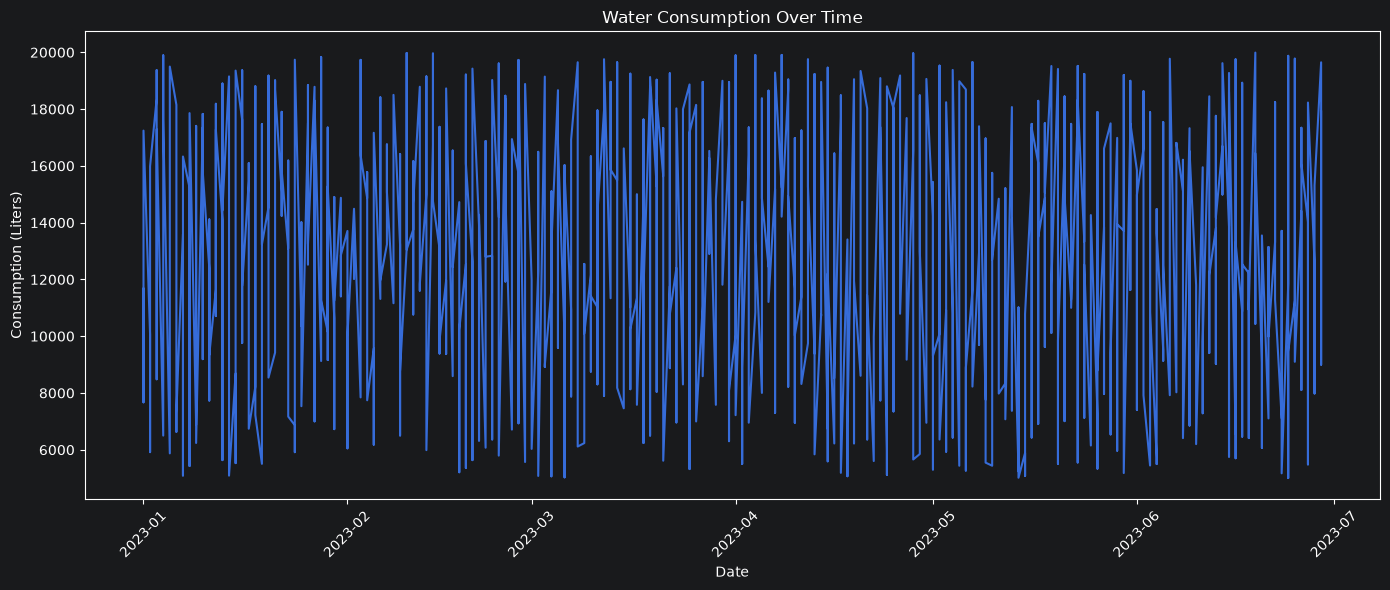

In [16]:
# Water consumption over time

plt.figure(figsize=(14, 6))

plt.plot(
    water_clean["date"],
    water_clean["consumption_liters"]
)

plt.title("Water Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Consumption (Liters)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# WATER CONSUMPTION — REGION-WISE ANALYSIS
# ============================================================

region_consumption = (
    water_clean
    .groupby("region")["consumption_liters"]
    .agg(["mean", "sum", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("Region-wise Water Consumption:")
print(region_consumption)

Region-wise Water Consumption:
                 mean         sum      min       max
region                                              
East     13102.412611  2358434.27  5014.83  19989.83
Central  13040.439889  2347279.18  5067.01  19739.44
North    12791.649667  2302496.94  5063.96  19892.73
West     12483.603056  2247048.55  5004.09  19906.71
South    12350.685833  2223123.45  5027.73  19975.27


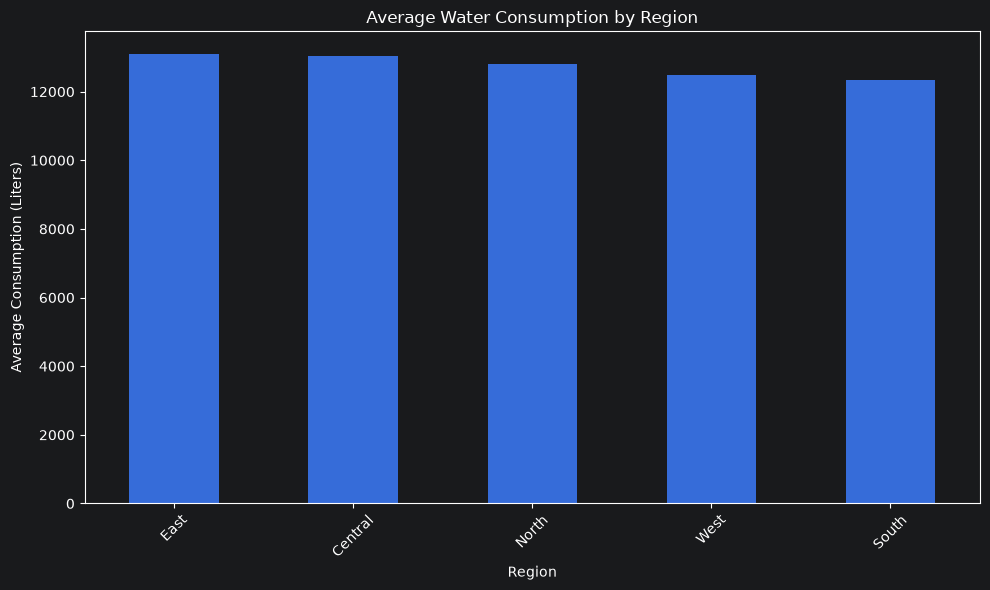

In [18]:
# Region-wise average consumption

plt.figure(figsize=(10, 6))

region_consumption["mean"].plot(
    kind="bar"
)

plt.title("Average Water Consumption by Region")
plt.xlabel("Region")
plt.ylabel("Average Consumption (Liters)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# EDA 2 — FLOOD RISK DATASET
# ============================================================

print("=" * 70)
print("FLOOD RISK — BASIC ANALYSIS")
print("=" * 70)

print("\nDataset shape:")
print(flood_clean.shape)

print("\nStatistical summary:")
print(flood_clean.describe())

print("\nTarget distribution:")
print(flood_clean["Flood Occurred"].value_counts())

print("\nTarget percentages:")
print(
    flood_clean["Flood Occurred"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

FLOOD RISK — BASIC ANALYSIS

Dataset shape:
(10000, 14)

Statistical summary:
           Latitude     Longitude  Rainfall (mm)  Temperature (°C)  \
count  10000.000000  10000.000000   10000.000000      10000.000000   
mean      22.330627     82.631366     150.015118         29.961401   
std        8.341274      8.389542      86.032127          8.669838   
min        8.000337     68.004575       0.014437         15.000166   
25%       15.143537     75.364428      76.124373         22.405717   
50%       22.283330     82.671007     150.620428         30.000907   
75%       29.460184     89.937897     223.402156         37.413488   
max       36.991813     96.997820     299.970293         44.993681   

       Humidity (%)  River Discharge (m³/s)  Water Level (m)  Elevation (m)  \
count  10000.000000            10000.000000     10000.000000   10000.000000   
mean      59.749104             2515.722946         5.017881    4417.138177   
std       23.142734             1441.706442         2.

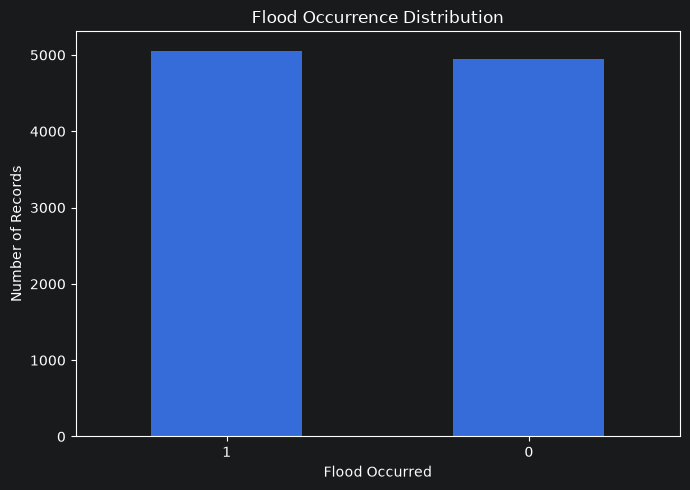

In [20]:
# Flood occurrence distribution

plt.figure(figsize=(7, 5))

flood_clean["Flood Occurred"].value_counts().plot(
    kind="bar"
)

plt.title("Flood Occurrence Distribution")
plt.xlabel("Flood Occurred")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

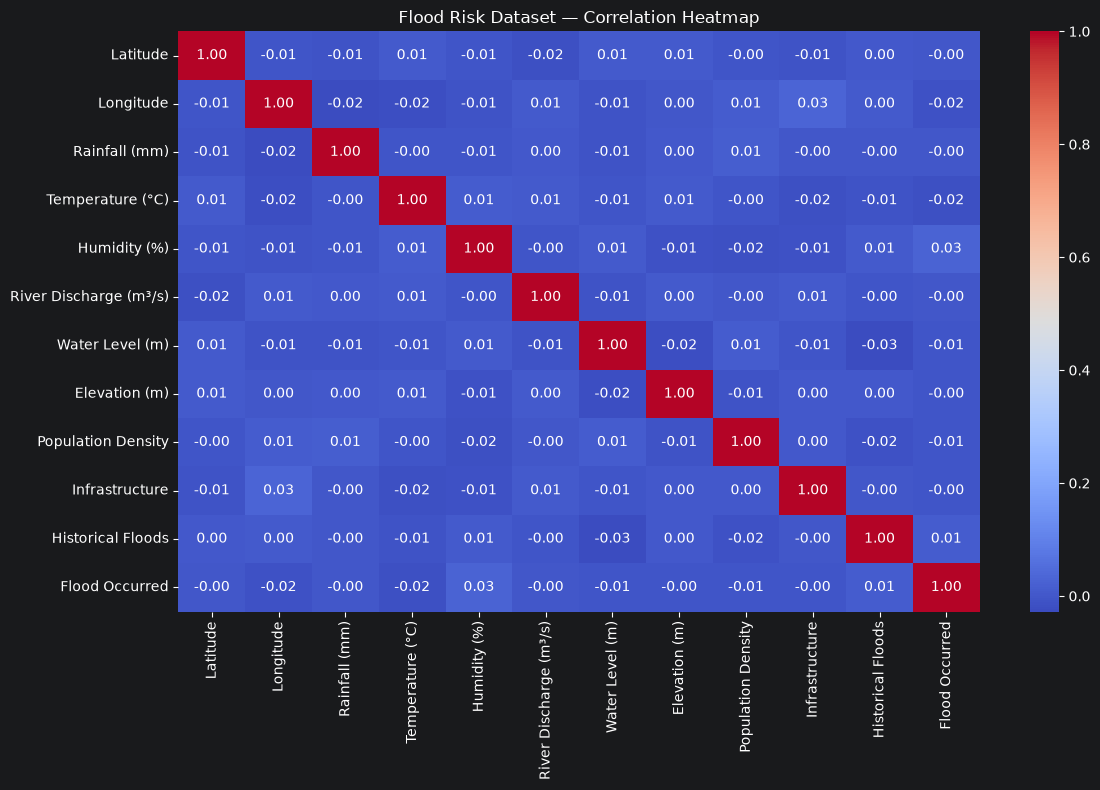

In [21]:
# ============================================================
# FLOOD RISK — CORRELATION ANALYSIS
# ============================================================

numeric_flood = flood_clean.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_flood.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Flood Risk Dataset — Correlation Heatmap")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# EDA 3 — RAINFALL DATASET
# ============================================================

print("=" * 70)
print("RAINFALL — BASIC ANALYSIS")
print("=" * 70)

print("\nDataset shape:")
print(rain_clean.shape)

print("\nStatistical summary:")
print(rain_clean.describe())

print("\nYears available:")
print(
    rain_clean["YEAR"].unique()
)

print("\nSub-divisions:")
print(
    rain_clean["SUBDIVISION"].unique()
)

RAINFALL — BASIC ANALYSIS

Dataset shape:
(4188, 19)

Statistical summary:
              YEAR          JAN          FEB          MAR          APR  \
count  4188.000000  4188.000000  4188.000000  4188.000000  4188.000000   
mean   1959.220630    18.925931    21.588610    27.384957    43.045463   
std      33.717097    33.779365    35.721216    46.900135    68.123769   
min    1901.000000     0.000000     0.000000     0.000000     0.000000   
25%    1930.000000     0.600000     0.500000     1.000000     3.000000   
50%    1959.000000     5.950000     6.500000     7.900000    15.450000   
75%    1988.000000    22.000000    26.600000    31.300000    49.525000   
max    2017.000000   583.700000   403.500000   605.600000   595.100000   

               MAY          JUN         JUL          AUG          SEP  \
count  4188.000000  4188.000000  4188.00000  4188.000000  4188.000000   
mean     85.625931   230.008453   346.91638   289.712345   197.282498   
std     122.658113   234.173390   268.6

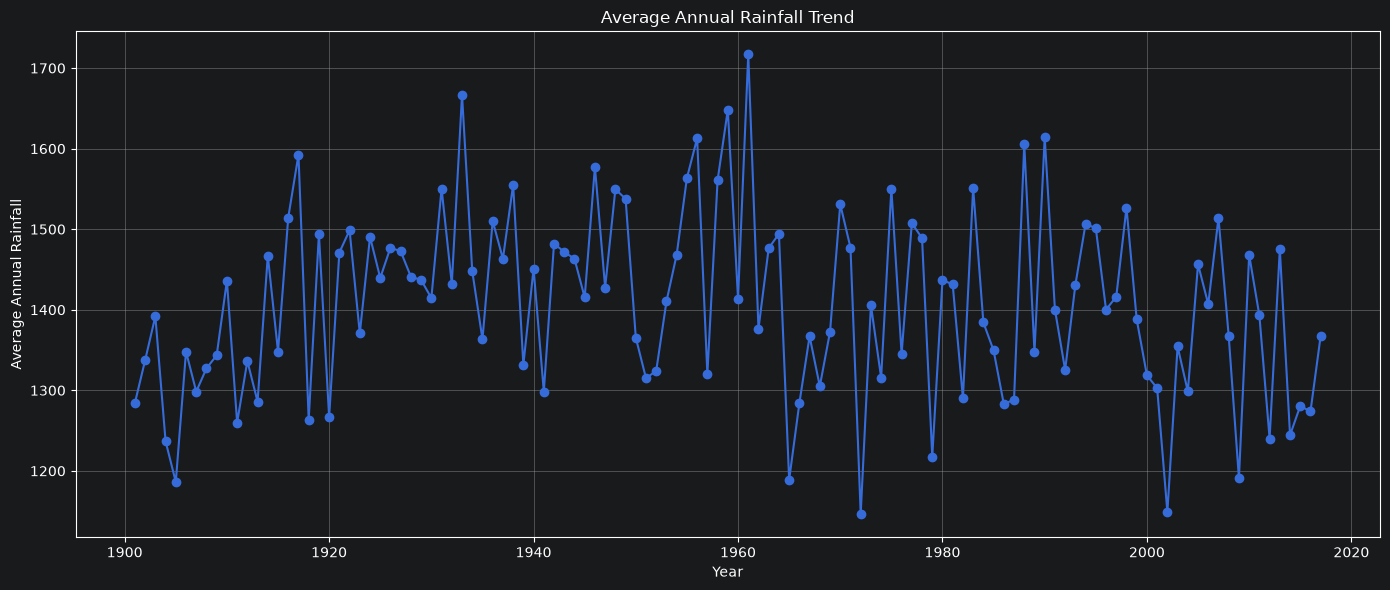

In [23]:
# ============================================================
# ANNUAL RAINFALL TREND
# ============================================================

annual_rainfall = (
    rain_clean
    .groupby("YEAR")["ANNUAL"]
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    annual_rainfall.index,
    annual_rainfall.values,
    marker="o"
)

plt.title("Average Annual Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Average Annual Rainfall")

plt.grid(True)
plt.tight_layout()
plt.show()

Monthly rainfall columns found:
['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

Average rainfall by month:
JAN     18.925931
FEB     21.588610
MAR     27.384957
APR     43.045463
MAY     85.625931
JUN    230.008453
JUL    346.916380
AUG    289.712345
SEP    197.282498
OCT     95.274355
NOV     39.417383
DEC     18.930516
dtype: float64


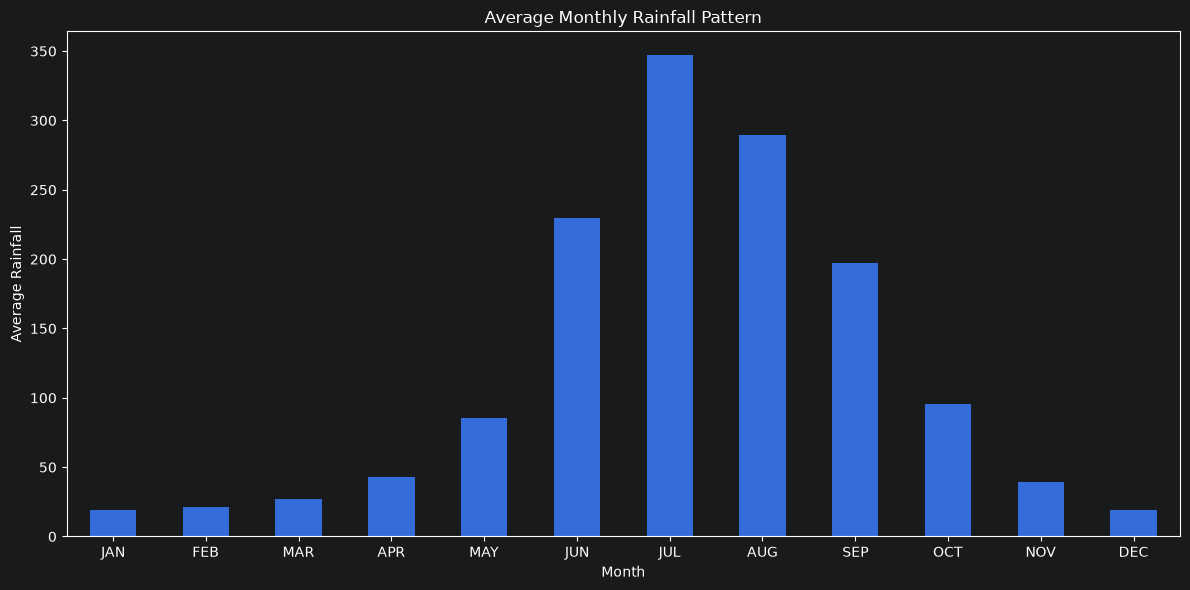

In [25]:
# ============================================================
# MONTHLY RAINFALL PATTERN
# ============================================================

# Monthly rainfall columns
month_columns = [
    "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
    "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"
]

# Keep only columns that actually exist
available_months = [
    col for col in month_columns
    if col in rain_clean.columns
]

print("Monthly rainfall columns found:")
print(available_months)

# Calculate average rainfall for each month
monthly_rainfall = rain_clean[available_months].mean()

print("\nAverage rainfall by month:")
print(monthly_rainfall)

# Visualization
plt.figure(figsize=(12, 6))

monthly_rainfall.plot(
    kind="bar"
)

plt.title("Average Monthly Rainfall Pattern")
plt.xlabel("Month")
plt.ylabel("Average Rainfall")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# EDA 4 — SOIL MOISTURE DATASET
# ============================================================

print("=" * 70)
print("SOIL MOISTURE — BASIC ANALYSIS")
print("=" * 70)

print("\nDataset shape:")
print(soil_clean.shape)

print("\nStatistical summary:")
print(soil_clean.describe())

print("\nDate range:")
print("Start:", soil_clean["Date"].min())
print("End  :", soil_clean["Date"].max())

if "DistrictName" in soil_clean.columns:
    print("\nNumber of districts:")
    print(soil_clean["DistrictName"].nunique())

print("\nSoil moisture target statistics:")

soil_target = [
    col for col in soil_clean.columns
    if "soilmoisture" in col.lower().replace(" ", "")
][0]

print("Target:", soil_target)
print(soil_clean[soil_target].describe())

SOIL MOISTURE — BASIC ANALYSIS

Dataset shape:
(2480, 7)

Statistical summary:
                             Date  Average Soilmoisture Level (at 15cm)  \
count                        2480                           2480.000000   
mean   2020-05-09 00:34:50.322580                              0.238048   
min           2020-01-01 00:00:00                              0.000000   
25%           2020-03-02 18:00:00                              0.000000   
50%           2020-05-03 12:00:00                              0.000000   
75%           2020-07-23 06:00:00                              0.220000   
max           2020-09-23 00:00:00                              7.790000   
std                           NaN                              0.576087   

       Average SoilMoisture Volume (at 15cm)  \
count                            2480.000000   
mean                             1763.697903   
min                                 1.990000   
25%                              1147.065000   
50%  

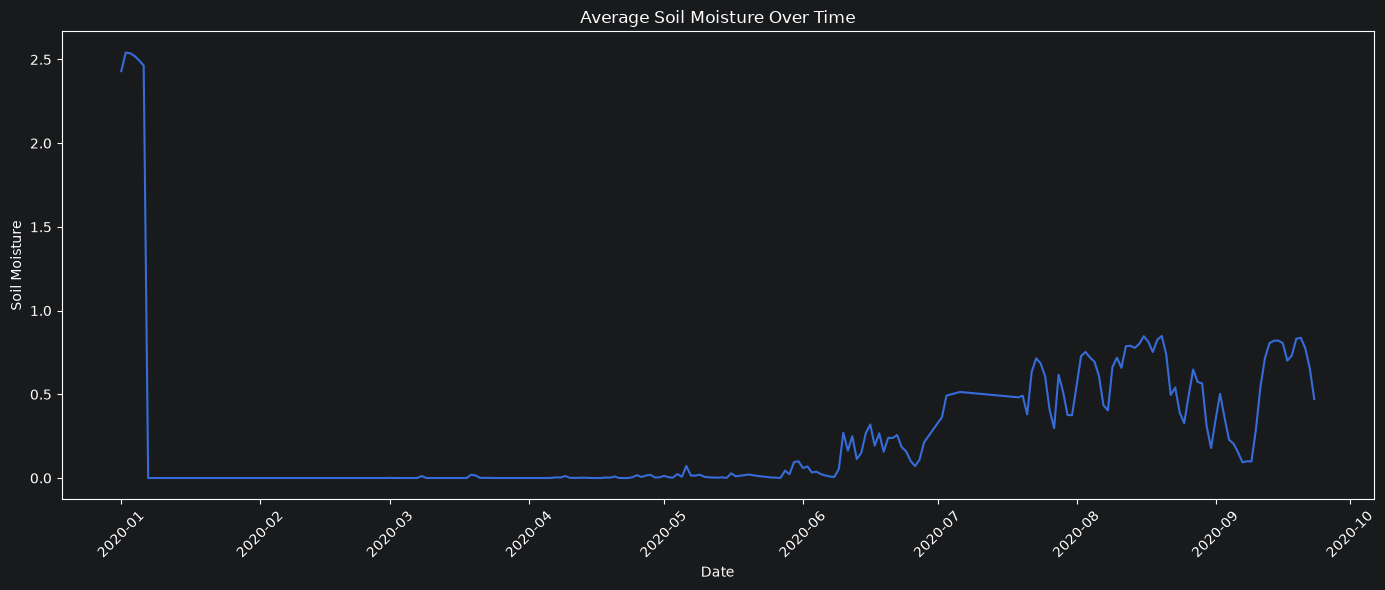

In [27]:
# ============================================================
# SOIL MOISTURE TREND
# ============================================================

daily_soil = (
    soil_clean
    .groupby("Date")[soil_target]
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_soil.index,
    daily_soil.values
)

plt.title("Average Soil Moisture Over Time")
plt.xlabel("Date")
plt.ylabel("Soil Moisture")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Average Soil Moisture by District:
DistrictName
WARANGAL       0.472863
KHAMMAM        0.359597
NALGONDA       0.339516
KARIMNAGAR     0.256008
MAHBUBNAGAR    0.190524
HYDERABAD      0.189516
NIZAMABAD      0.180363
ADILABAD       0.159718
MEDAK          0.156734
RANGAREDDY     0.075645
Name: Average Soilmoisture Level (at 15cm), dtype: float64


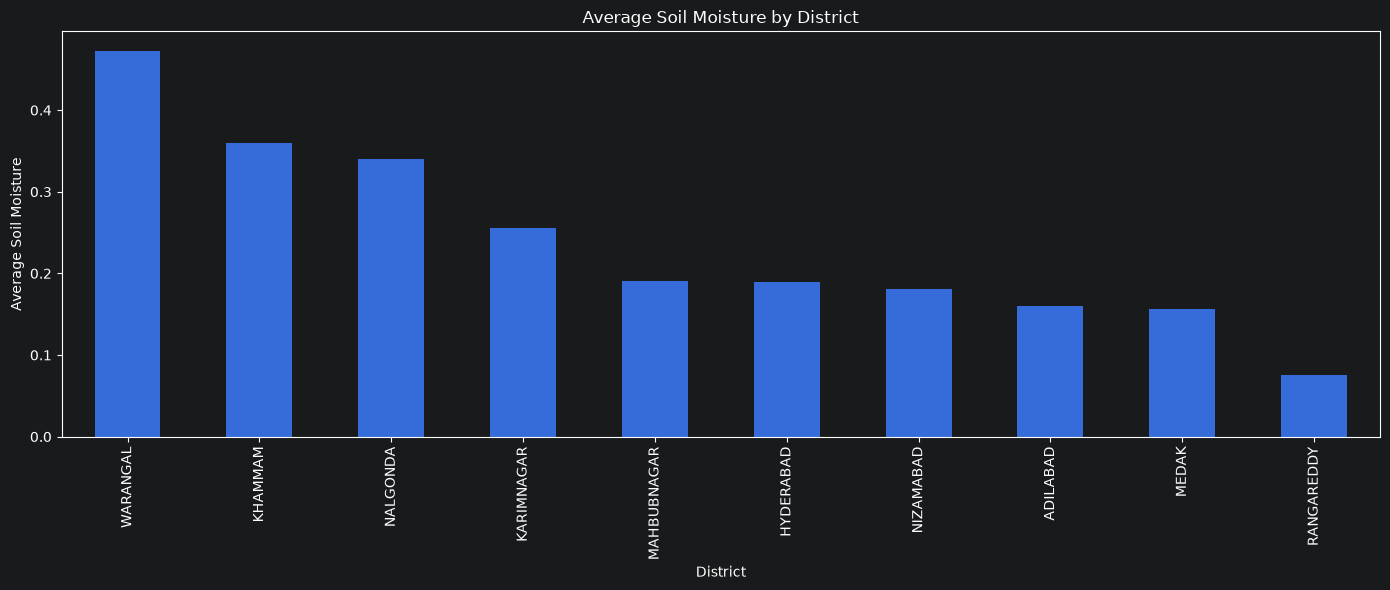

In [28]:
# ============================================================
# DISTRICT-WISE SOIL MOISTURE
# ============================================================

if "DistrictName" in soil_clean.columns:

    district_soil = (
        soil_clean
        .groupby("DistrictName")[soil_target]
        .mean()
        .sort_values(ascending=False)
    )

    print("Average Soil Moisture by District:")
    print(district_soil)

    plt.figure(figsize=(14, 6))

    district_soil.plot(
        kind="bar"
    )

    plt.title("Average Soil Moisture by District")
    plt.xlabel("District")
    plt.ylabel("Average Soil Moisture")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

In [29]:
# ============================================================
# FEATURE ENGINEERING — WATER CONSUMPTION
# ============================================================

water_features = water_clean.copy()

# Date-based features
water_features["year"] = water_features["date"].dt.year
water_features["month"] = water_features["date"].dt.month
water_features["day"] = water_features["date"].dt.day
water_features["day_of_week"] = water_features["date"].dt.dayofweek
water_features["day_of_year"] = water_features["date"].dt.dayofyear
water_features["week_of_year"] = (
    water_features["date"].dt.isocalendar().week.astype(int)
)

# Weekend indicator
water_features["is_weekend"] = (
    water_features["day_of_week"] >= 5
).astype(int)

# Seasonal features
water_features["sin_month"] = np.sin(
    2 * np.pi * water_features["month"] / 12
)

water_features["cos_month"] = np.cos(
    2 * np.pi * water_features["month"] / 12
)

# Lag features
water_features["consumption_lag_1"] = (
    water_features
    .groupby("region")["consumption_liters"]
    .shift(1)
)

water_features["consumption_lag_7"] = (
    water_features
    .groupby("region")["consumption_liters"]
    .shift(7)
)

# Rolling average
water_features["consumption_rolling_7"] = (
    water_features
    .groupby("region")["consumption_liters"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

print("=" * 70)
print("WATER FEATURE ENGINEERING")
print("=" * 70)

print("\nNew shape:")
print(water_features.shape)

print("\nNew features:")
print(water_features.columns.tolist())

print("\nMissing values created by lag/rolling features:")
print(
    water_features[
        [
            "consumption_lag_1",
            "consumption_lag_7",
            "consumption_rolling_7"
        ]
    ].isnull().sum()
)

WATER FEATURE ENGINEERING

New shape:
(900, 15)

New features:
['region', 'date', 'consumption_liters', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'is_weekend', 'sin_month', 'cos_month', 'consumption_lag_1', 'consumption_lag_7', 'consumption_rolling_7']

Missing values created by lag/rolling features:
consumption_lag_1         5
consumption_lag_7        35
consumption_rolling_7    35
dtype: int64


In [30]:
# ============================================================
# FEATURE ENGINEERING — FLOOD RISK
# ============================================================

flood_features = flood_clean.copy()

# Separate target
flood_target = "Flood Occurred"

# Identify feature columns
flood_feature_columns = [
    col for col in flood_features.columns
    if col != flood_target
]

# Identify numerical and categorical features
flood_numeric_features = flood_features[
    flood_feature_columns
].select_dtypes(include=np.number).columns.tolist()

flood_categorical_features = flood_features[
    flood_feature_columns
].select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("=" * 70)
print("FLOOD RISK FEATURE ENGINEERING")
print("=" * 70)

print("\nTarget:")
print(flood_target)

print("\nNumerical features:")
print(flood_numeric_features)

print("\nCategorical features:")
print(flood_categorical_features)

print("\nTotal features:", len(flood_feature_columns))

FLOOD RISK FEATURE ENGINEERING

Target:
Flood Occurred

Numerical features:
['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Population Density', 'Infrastructure', 'Historical Floods']

Categorical features:
['Land Cover', 'Soil Type']

Total features: 13


In [31]:
# ============================================================
# FLOOD RISK — FEATURE SUMMARY
# ============================================================

print("=" * 70)
print("FLOOD FEATURE SUMMARY")
print("=" * 70)

for col in flood_feature_columns:
    print(
        f"{col:30} | "
        f"Unique values: {flood_features[col].nunique()}"
    )

FLOOD FEATURE SUMMARY
Latitude                       | Unique values: 10000
Longitude                      | Unique values: 10000
Rainfall (mm)                  | Unique values: 10000
Temperature (°C)               | Unique values: 10000
Humidity (%)                   | Unique values: 10000
River Discharge (m³/s)         | Unique values: 10000
Water Level (m)                | Unique values: 10000
Elevation (m)                  | Unique values: 10000
Land Cover                     | Unique values: 5
Soil Type                      | Unique values: 5
Population Density             | Unique values: 10000
Infrastructure                 | Unique values: 2
Historical Floods              | Unique values: 2


In [32]:
# ============================================================
# FEATURE ENGINEERING — RAINFALL
# ============================================================

rain_features = rain_clean.copy()

# Convert year to numeric
rain_features["YEAR"] = pd.to_numeric(
    rain_features["YEAR"],
    errors="coerce"
)

# Create rainfall variability features
month_columns = [
    "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
    "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"
]

available_months = [
    col for col in month_columns
    if col in rain_features.columns
]

# Average monthly rainfall
rain_features["monthly_rainfall_mean"] = (
    rain_features[available_months].mean(axis=1)
)

# Maximum monthly rainfall
rain_features["monthly_rainfall_max"] = (
    rain_features[available_months].max(axis=1)
)

# Minimum monthly rainfall
rain_features["monthly_rainfall_min"] = (
    rain_features[available_months].min(axis=1)
)

# Rainfall standard deviation
rain_features["monthly_rainfall_std"] = (
    rain_features[available_months].std(axis=1)
)

# Rainfall range
rain_features["monthly_rainfall_range"] = (
    rain_features["monthly_rainfall_max"]
    - rain_features["monthly_rainfall_min"]
)

print("=" * 70)
print("RAINFALL FEATURE ENGINEERING")
print("=" * 70)

print("\nMonthly columns used:")
print(available_months)

print("\nNew shape:")
print(rain_features.shape)

print("\nNew rainfall features:")
print([
    "monthly_rainfall_mean",
    "monthly_rainfall_max",
    "monthly_rainfall_min",
    "monthly_rainfall_std",
    "monthly_rainfall_range"
])

RAINFALL FEATURE ENGINEERING

Monthly columns used:
['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

New shape:
(4188, 24)

New rainfall features:
['monthly_rainfall_mean', 'monthly_rainfall_max', 'monthly_rainfall_min', 'monthly_rainfall_std', 'monthly_rainfall_range']


In [33]:
# ============================================================
# FEATURE ENGINEERING — SOIL MOISTURE
# ============================================================

soil_features = soil_clean.copy()

# Automatically identify target
soil_target = [
    col for col in soil_features.columns
    if "soilmoisture" in col.lower().replace(" ", "")
][0]

# Time-based features
soil_features["year"] = (
    soil_features["Date"].dt.year
)

soil_features["month"] = (
    soil_features["Date"].dt.month
)

soil_features["day"] = (
    soil_features["Date"].dt.day
)

# Cyclic month features
soil_features["month_sin"] = np.sin(
    2 * np.pi * soil_features["month"] / 12
)

soil_features["month_cos"] = np.cos(
    2 * np.pi * soil_features["month"] / 12
)

# District-wise rolling soil moisture
if "DistrictName" in soil_features.columns:

    soil_features["soil_moisture_7day_avg"] = (
        soil_features
        .groupby("DistrictName")[soil_target]
        .transform(
            lambda x: x.shift(1).rolling(7).mean()
        )
    )

else:

    soil_features["soil_moisture_7day_avg"] = (
        soil_features[soil_target]
        .shift(1)
        .rolling(7)
        .mean()
    )

print("=" * 70)
print("SOIL MOISTURE FEATURE ENGINEERING")
print("=" * 70)

print("\nTarget:", soil_target)

print("\nNew shape:")
print(soil_features.shape)

print("\nNew features:")
print([
    "year",
    "month",
    "day",
    "month_sin",
    "month_cos",
    "soil_moisture_7day_avg"
])

print("\nMissing values created by rolling feature:")
print(
    soil_features["soil_moisture_7day_avg"].isnull().sum()
)

SOIL MOISTURE FEATURE ENGINEERING

Target: Average Soilmoisture Level (at 15cm)

New shape:
(2480, 13)

New features:
['year', 'month', 'day', 'month_sin', 'month_cos', 'soil_moisture_7day_avg']

Missing values created by rolling feature:
70


In [34]:
# ============================================================
# SAVE FEATURE-ENGINEERED DATASETS
# ============================================================

# Save Water features
water_features.to_csv(
    FEATURE_DIR / "water_features.csv",
    index=False
)

# Save Flood features
flood_features.to_csv(
    FEATURE_DIR / "flood_features.csv",
    index=False
)

# Save Rainfall features
rain_features.to_csv(
    FEATURE_DIR / "rainfall_features.csv",
    index=False
)

# Save Soil Moisture features
soil_features.to_csv(
    FEATURE_DIR / "soil_moisture_features.csv",
    index=False
)

print("=" * 70)
print("FEATURE DATASETS SAVED")
print("=" * 70)

for file in FEATURE_DIR.glob("*.csv"):
    print("✓", file.name)

FEATURE DATASETS SAVED
✓ flood_features.csv
✓ rainfall_features.csv
✓ soil_moisture_features.csv
✓ water_features.csv


In [35]:
# ============================================================
# VERIFY FEATURE DATASETS
# ============================================================

for file in FEATURE_DIR.glob("*.csv"):

    df = pd.read_csv(file)

    print("\n" + "-" * 60)
    print(file.name)
    print("Rows    :", df.shape[0])
    print("Columns :", df.shape[1])


------------------------------------------------------------
flood_features.csv
Rows    : 10000
Columns : 14

------------------------------------------------------------
rainfall_features.csv
Rows    : 4188
Columns : 24

------------------------------------------------------------
soil_moisture_features.csv
Rows    : 2480
Columns : 13

------------------------------------------------------------
water_features.csv
Rows    : 900
Columns : 15


In [36]:
# ============================================================
# MODEL 1 — WATER CONSUMPTION PREDICTION
# DATA PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Copy feature dataset
water_model = water_features.copy()

# Sort chronologically
water_model = water_model.sort_values("date")

# Remove rows created with missing lag/rolling values
water_model = water_model.dropna()

# Target
target = "consumption_liters"

# Features to use
features = [
    "region",
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "is_weekend",
    "sin_month",
    "cos_month",
    "consumption_lag_1",
    "consumption_lag_7",
    "consumption_rolling_7"
]

X = water_model[features]
y = water_model[target]

# Identify categorical and numerical columns
categorical_features = ["region"]

numerical_features = [
    col for col in features
    if col not in categorical_features
]

# Chronological 80/20 split
split_index = int(len(water_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("=" * 70)
print("WATER MODEL DATA PREPARATION")
print("=" * 70)

print("Total samples :", len(water_model))
print("Training data :", len(X_train))
print("Testing data  :", len(X_test))

print("\nTraining period:")
print(water_model["date"].iloc[0], "→",
      water_model["date"].iloc[split_index - 1])

print("\nTesting period:")
print(water_model["date"].iloc[split_index], "→",
      water_model["date"].iloc[-1])

WATER MODEL DATA PREPARATION
Total samples : 865
Training data : 692
Testing data  : 173

Training period:
2023-01-08 00:00:00 → 2023-05-26 00:00:00

Testing period:
2023-05-26 00:00:00 → 2023-06-29 00:00:00


In [37]:
# ============================================================
# WATER CONSUMPTION — MODEL TRAINING
# ============================================================

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# Models
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
}

results = []
trained_models = {}

# Train and evaluate each model
for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    predictions = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_models[name] = pipeline

# Results table
water_results = pd.DataFrame(results)

print("=" * 70)
print("WATER CONSUMPTION MODEL RESULTS")
print("=" * 70)

print(
    water_results
    .sort_values("RMSE")
    .to_string(index=False)
)

WATER CONSUMPTION MODEL RESULTS
            Model         MAE        RMSE  R2 Score
Linear Regression 3537.789608 4141.359864 -0.003695
    Random Forest 3757.667036 4402.715452 -0.134376
Gradient Boosting 4007.644614 4846.887857 -0.374806
    Decision Tree 4461.318887 5482.431464 -0.758985


,Model,MAE,RMSE,R2 Score
0,Linear Regression,3537.789608,4141.359864,-0.003695
2,Random Forest,3757.667036,4402.715452,-0.134376
3,Gradient Boosting,4007.644614,4846.887857,-0.374806
1,Decision Tree,4461.318887,5482.431464,-0.758985


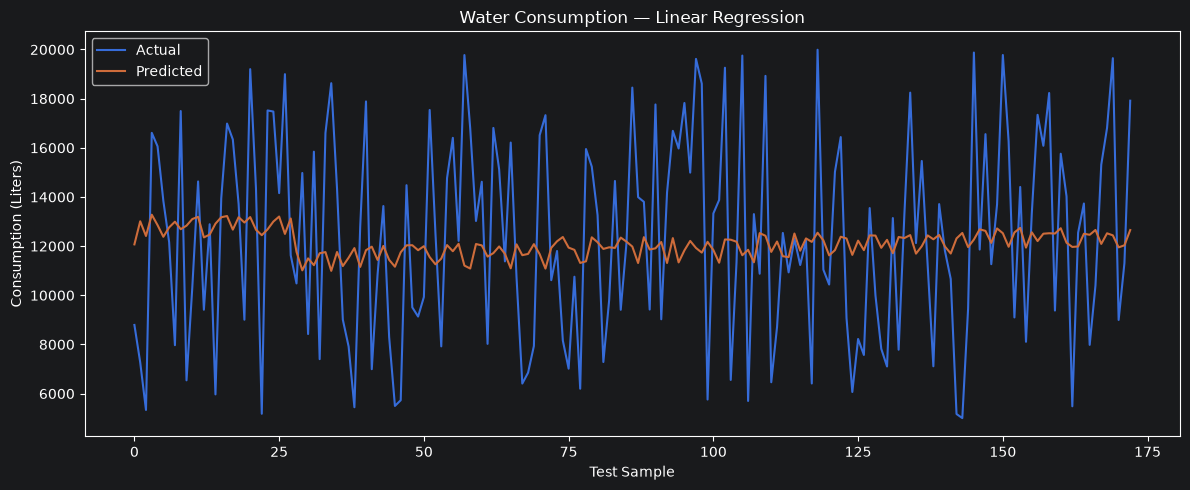

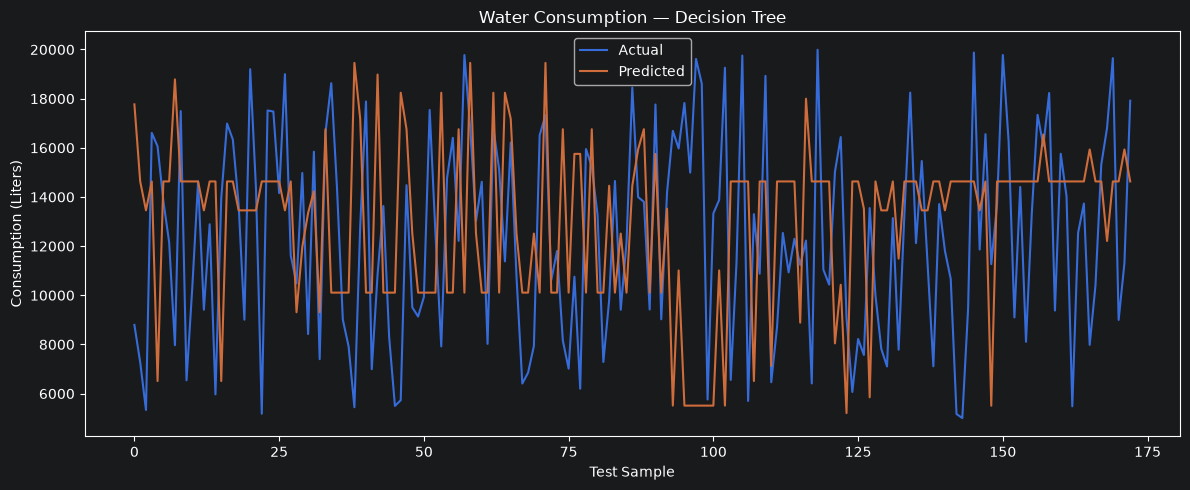

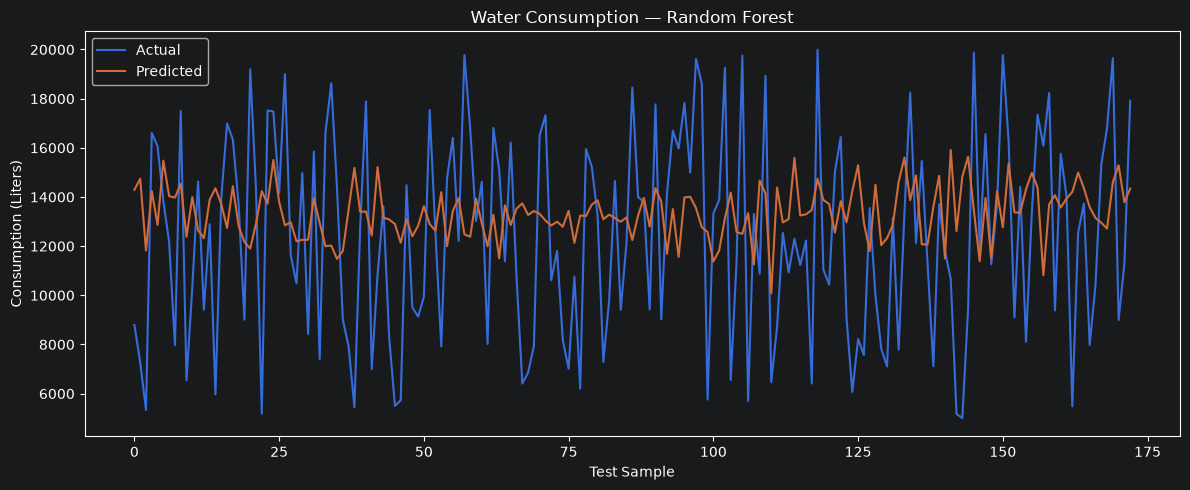

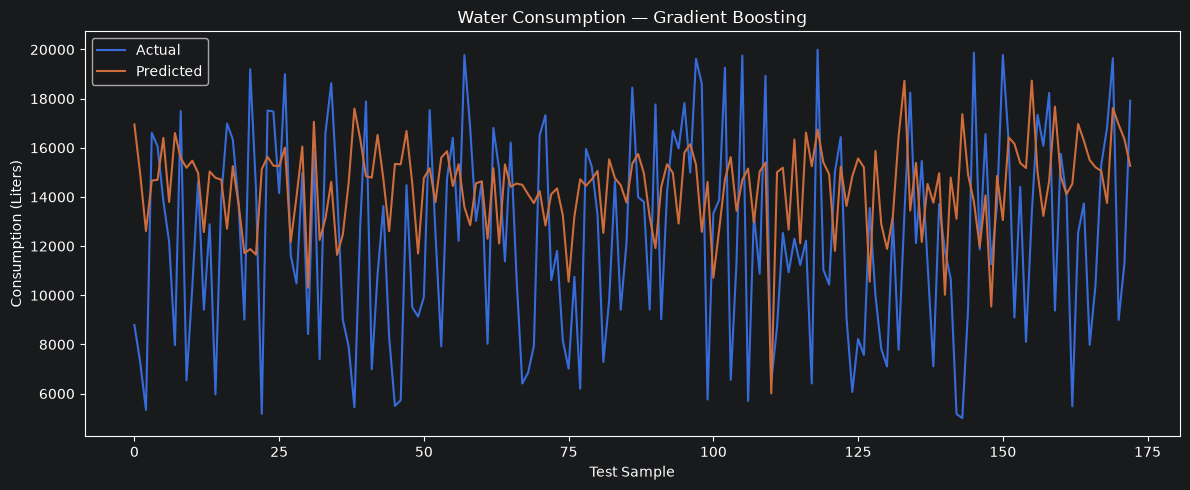

In [38]:
# ============================================================
# WATER CONSUMPTION — ACTUAL VS PREDICTED
# ============================================================

# Sort results by RMSE
water_results = water_results.sort_values("RMSE")

# Display results
display(water_results)

# Get model names
model_names = list(trained_models.keys())

for name in model_names:

    model = trained_models[name]

    predictions = model.predict(X_test)

    plt.figure(figsize=(12, 5))

    plt.plot(
        y_test.values,
        label="Actual"
    )

    plt.plot(
        predictions,
        label="Predicted"
    )

    plt.title(
        f"Water Consumption — {name}"
    )

    plt.xlabel("Test Sample")
    plt.ylabel("Consumption (Liters)")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [39]:
# ============================================================
# SAVE WATER MODELS AND RESULTS
# ============================================================

import joblib

# Save every trained model
for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        + "_water_model.pkl"
    )

    joblib.dump(
        model,
        MODEL_DIR / filename
    )

# Save evaluation results
water_results.to_csv(
    REPORT_DIR / "water_model_results.csv",
    index=False
)

print("=" * 70)
print("WATER MODELS SAVED")
print("=" * 70)

for file in MODEL_DIR.glob("*water_model.pkl"):
    print("✓", file.name)

print("\nResults saved to:")
print(REPORT_DIR / "water_model_results.csv")

WATER MODELS SAVED
✓ decision_tree_water_model.pkl
✓ gradient_boosting_water_model.pkl
✓ linear_regression_water_model.pkl
✓ random_forest_water_model.pkl

Results saved to:
C:\Users\kvaad\OneDrive\Desktop\ML water-intelligence\reports\water_model_results.csv


In [40]:
# ============================================================
# MODEL 2 — FLOOD RISK CLASSIFICATION
# DATA PREPARATION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Copy dataset
flood_model = flood_features.copy()

# Target
flood_target = "Flood Occurred"

# Separate X and y
X = flood_model.drop(
    columns=[flood_target]
)

y = flood_model[flood_target]

# Identify numerical columns
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

# Identify categorical columns
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("=" * 70)
print("FLOOD RISK MODEL PREPARATION")
print("=" * 70)

print("\nTarget:", flood_target)

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal samples:", len(X))

print("\nTarget distribution:")
print(y.value_counts())

FLOOD RISK MODEL PREPARATION

Target: Flood Occurred

Numerical features:
['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Population Density', 'Infrastructure', 'Historical Floods']

Categorical features:
['Land Cover', 'Soil Type']

Total samples: 10000

Target distribution:
Flood Occurred
1    5057
0    4943
Name: count, dtype: int64


In [41]:
# ============================================================
# FLOOD RISK — MODEL TRAINING
# ============================================================

# Preprocessing pipeline
flood_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Classification models
flood_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
}

flood_trained_models = {}
flood_results = []

# Stratified train-test split
X_train_flood, X_test_flood, y_train_flood, y_test_flood = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print("=" * 70)
print("FLOOD RISK MODEL TRAINING")
print("=" * 70)

print("Training samples:", len(X_train_flood))
print("Testing samples :", len(X_test_flood))

# Train each model
for name, model in flood_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", flood_preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(
        X_train_flood,
        y_train_flood
    )

    # Predictions
    predictions = pipeline.predict(
        X_test_flood
    )

    # Probability for ROC-AUC
    probabilities = pipeline.predict_proba(
        X_test_flood
    )[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_test_flood,
        predictions
    )

    precision = precision_score(
        y_test_flood,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test_flood,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test_flood,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_flood,
        probabilities
    )

    flood_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    flood_trained_models[name] = pipeline

# Results table
flood_results = pd.DataFrame(
    flood_results
)

print("\n" + "=" * 70)
print("FLOOD RISK MODEL RESULTS")
print("=" * 70)

print(
    flood_results.to_string(index=False)
)

FLOOD RISK MODEL TRAINING
Training samples: 8000
Testing samples : 2000

FLOOD RISK MODEL RESULTS
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression    0.4965   0.501733 0.572700  0.534873 0.498533
      Decision Tree    0.4980   0.504775 0.365974  0.424312 0.504368
      Random Forest    0.4995   0.504604 0.542038  0.522651 0.503436
  Gradient Boosting    0.5095   0.513465 0.565776  0.538353 0.502703


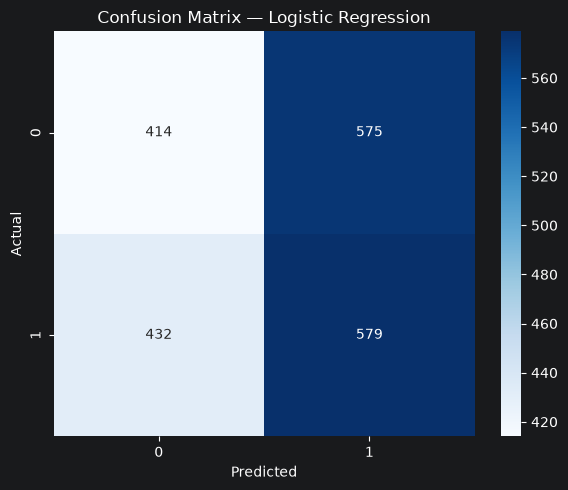

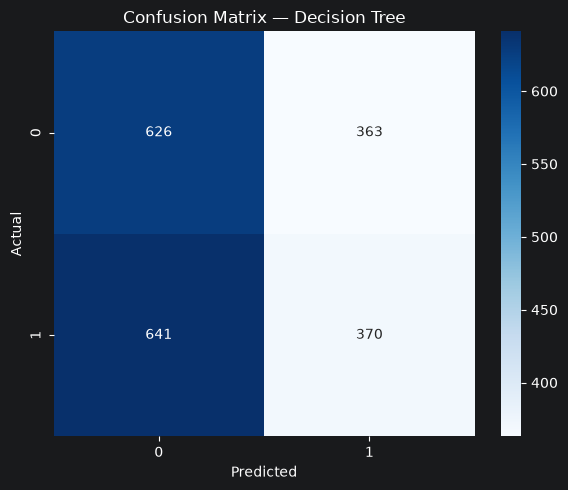

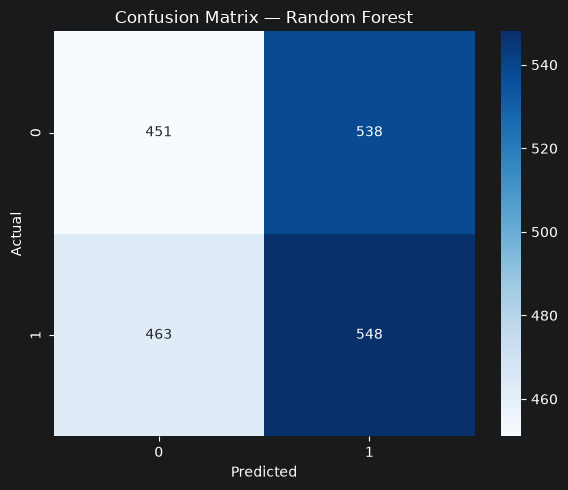

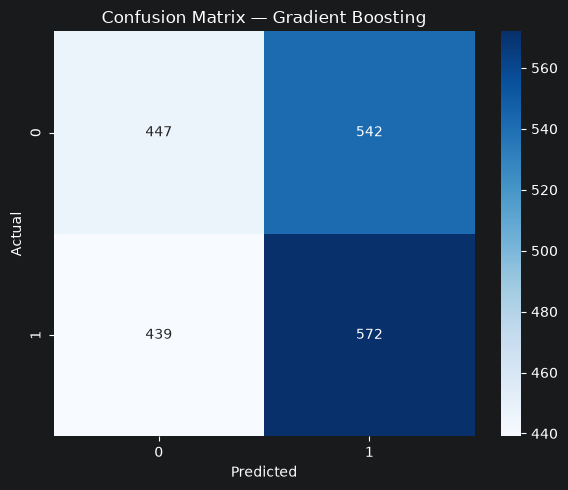

In [42]:
# ============================================================
# FLOOD RISK — CONFUSION MATRICES
# ============================================================

for name, model in flood_trained_models.items():

    predictions = model.predict(
        X_test_flood
    )

    cm = confusion_matrix(
        y_test_flood,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix — {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

In [43]:
# ============================================================
# SAVE FLOOD RISK MODELS AND RESULTS
# ============================================================

import joblib

# Save trained models
for name, model in flood_trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        + "_flood_model.pkl"
    )

    joblib.dump(
        model,
        MODEL_DIR / filename
    )

# Save evaluation results
flood_results.to_csv(
    REPORT_DIR / "flood_model_results.csv",
    index=False
)

print("=" * 70)
print("FLOOD RISK MODELS SAVED")
print("=" * 70)

for file in MODEL_DIR.glob("*flood_model.pkl"):
    print("✓", file.name)

print("\nResults saved to:")
print(REPORT_DIR / "flood_model_results.csv")

FLOOD RISK MODELS SAVED
✓ decision_tree_flood_model.pkl
✓ gradient_boosting_flood_model.pkl
✓ logistic_regression_flood_model.pkl
✓ random_forest_flood_model.pkl

Results saved to:
C:\Users\kvaad\OneDrive\Desktop\ML water-intelligence\reports\flood_model_results.csv


In [44]:
# ============================================================
# UNSUPERVISED ML — K-MEANS CLUSTERING
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Select numerical features
cluster_data = flood_clean.select_dtypes(
    include=np.number
).copy()

# Remove target if present
if "Flood Occurred" in cluster_data.columns:
    cluster_data = cluster_data.drop(
        columns=["Flood Occurred"]
    )

# Handle any remaining missing values
cluster_data = cluster_data.fillna(
    cluster_data.median()
)

# Scale the data
cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_data
)

print("=" * 70)
print("K-MEANS CLUSTERING — DATA PREPARATION")
print("=" * 70)

print("Original shape:", cluster_data.shape)
print("Scaled shape  :", cluster_scaled.shape)
print("\nFeatures used:")
print(cluster_data.columns.tolist())

K-MEANS CLUSTERING — DATA PREPARATION
Original shape: (10000, 11)
Scaled shape  : (10000, 11)

Features used:
['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Population Density', 'Infrastructure', 'Historical Floods']


   K  Silhouette Score
0  2          0.093141
1  3          0.076788
2  4          0.100928
3  5          0.084084
4  6          0.075530
5  7          0.072911
6  8          0.077250


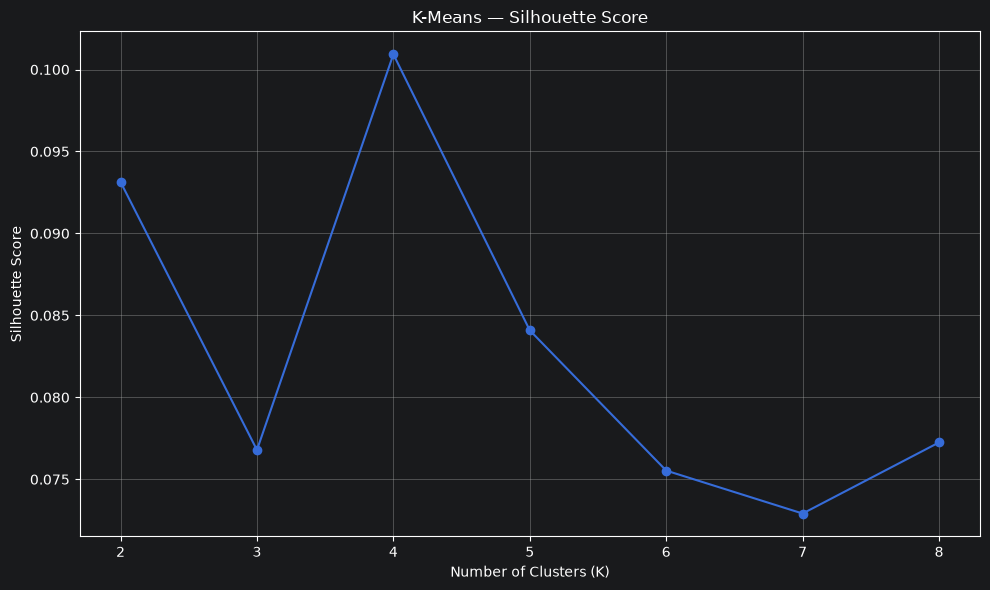

In [45]:
# ============================================================
# FIND OPTIMAL K USING SILHOUETTE SCORE
# ============================================================

k_values = range(2, 9)

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        cluster_scaled
    )

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    silhouette_scores.append(score)

# Display scores
cluster_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_scores
})

print(cluster_evaluation)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("K-Means — Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(k_values))
plt.grid(True)

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# K-MEANS CLUSTERING
# ============================================================

# Automatically select K with the highest silhouette score
best_k = cluster_evaluation.loc[
    cluster_evaluation["Silhouette Score"].idxmax(),
    "K"
]

best_k = int(best_k)

print("Selected K:", best_k)

# Train final K-Means model
kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(
    cluster_scaled
)

# Add cluster labels to a copy of the data
clustered_data = cluster_data.copy()

clustered_data["Cluster"] = cluster_labels

print("\nCluster distribution:")
print(
    clustered_data["Cluster"]
    .value_counts()
    .sort_index()
)

Selected K: 4

Cluster distribution:
Cluster
0    2495
1    2488
2    2525
3    2492
Name: count, dtype: int64


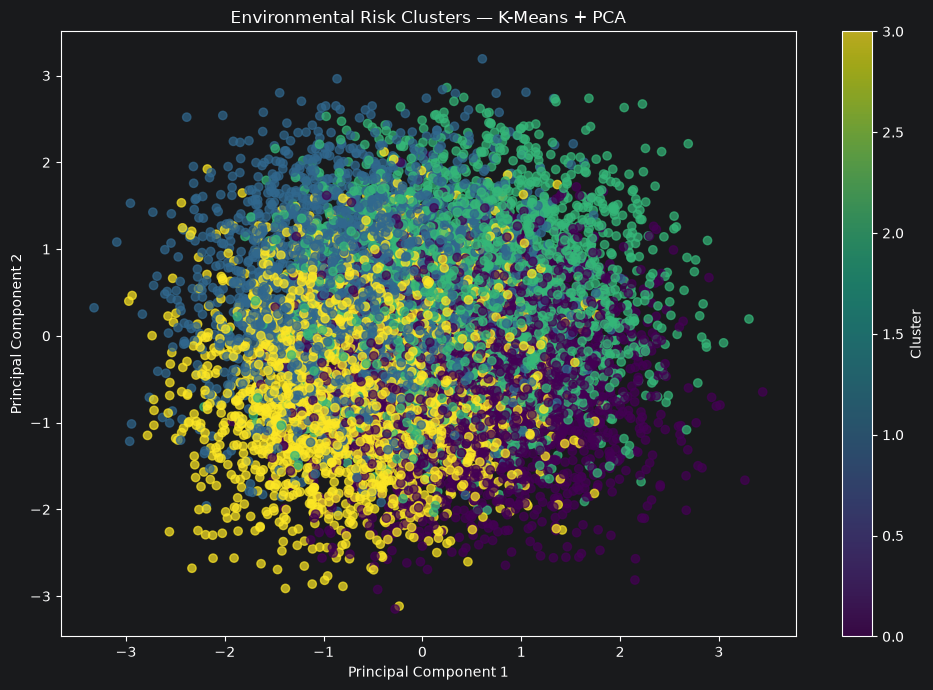

Explained variance ratio:
[0.09680387 0.09513858]

Total variance explained: 0.19194244886583053


In [47]:
# ============================================================
# PCA FOR CLUSTER VISUALIZATION
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

cluster_pca = pca.fit_transform(
    cluster_scaled
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    cluster_pca[:, 0],
    cluster_pca[:, 1],
    c=cluster_labels,
    alpha=0.7
)

plt.title("Environmental Risk Clusters — K-Means + PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()
plt.show()

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained:",
    pca.explained_variance_ratio_.sum()
)

In [48]:
# ============================================================
# CLUSTER PROFILE
# ============================================================

cluster_profile = (
    clustered_data
    .groupby("Cluster")
    .mean(numeric_only=True)
)

print("=" * 70)
print("CLUSTER PROFILES")
print("=" * 70)

display(cluster_profile)

CLUSTER PROFILES


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods
Cluster,,,,,,,,,,,
0,22.227751,82.957482,147.377945,29.681377,59.591222,2515.275810,4.929041,4391.910144,5008.364114,1.0,1.0
1,22.380690,82.336976,147.801315,30.161397,59.830986,2510.202979,5.126000,4376.779814,5079.283951,0.0,0.0
2,22.246270,82.845039,152.484485,29.912395,59.343089,2534.676896,5.068095,4453.367418,5050.323512,1.0,0.0
3,22.469118,82.382274,152.363650,30.091744,60.236819,2502.476781,4.948005,4445.981160,4947.628660,0.0,1.0


In [49]:
# ============================================================
# ANOMALY DETECTION — ISOLATION FOREST
# ============================================================

from sklearn.ensemble import IsolationForest

# Create Isolation Forest model
isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Train and predict
anomaly_labels = isolation_model.fit_predict(
    cluster_scaled
)

# Convert labels:
#  1  = Normal
# -1  = Anomaly

clustered_data["Anomaly"] = anomaly_labels

# Count results
anomaly_counts = clustered_data["Anomaly"].value_counts()

print("=" * 70)
print("ISOLATION FOREST — ANOMALY DETECTION")
print("=" * 70)

print("\nNormal observations:",
      anomaly_counts.get(1, 0))

print("Anomalous observations:",
      anomaly_counts.get(-1, 0))

print(
    "\nAnomaly percentage:",
    round(
        (anomaly_counts.get(-1, 0) / len(clustered_data)) * 100,
        2
    ),
    "%"
)

ISOLATION FOREST — ANOMALY DETECTION

Normal observations: 9500
Anomalous observations: 500

Anomaly percentage: 5.0 %


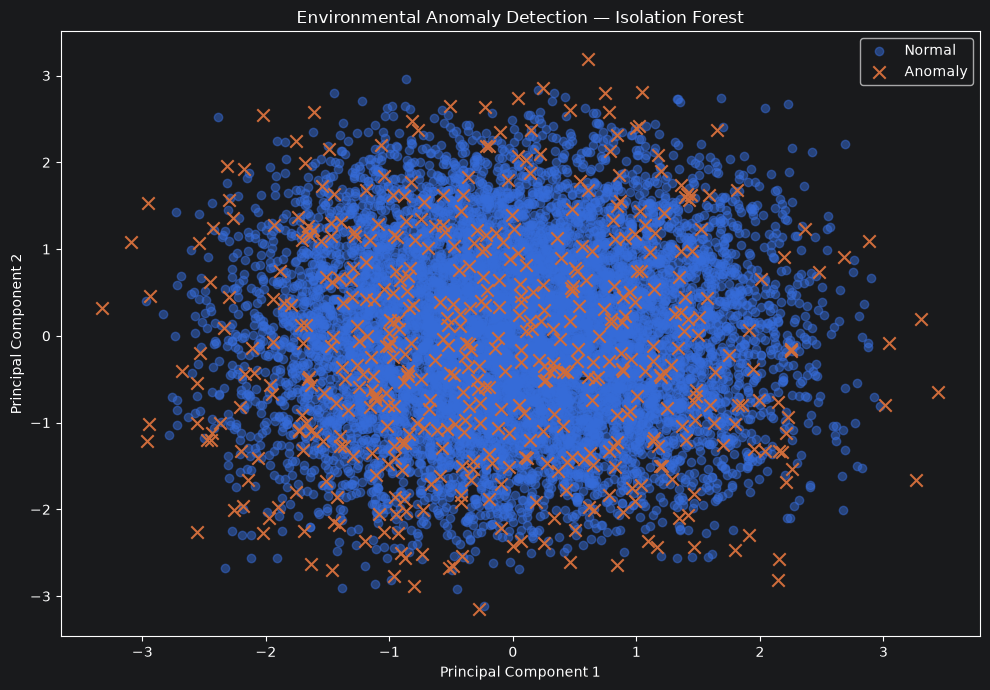

In [50]:
# ============================================================
# ANOMALY VISUALIZATION
# ============================================================

normal = anomaly_labels == 1
anomaly = anomaly_labels == -1

plt.figure(figsize=(10, 7))

plt.scatter(
    cluster_pca[normal, 0],
    cluster_pca[normal, 1],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    cluster_pca[anomaly, 0],
    cluster_pca[anomaly, 1],
    marker="x",
    s=80,
    label="Anomaly"
)

plt.title(
    "Environmental Anomaly Detection — Isolation Forest"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# ANOMALOUS RECORDS
# ============================================================

anomalies = clustered_data[
    clustered_data["Anomaly"] == -1
]

print("=" * 70)
print("ANOMALOUS ENVIRONMENTAL OBSERVATIONS")
print("=" * 70)

print("\nNumber of anomalies:", len(anomalies))

display(
    anomalies.head(20)
)

ANOMALOUS ENVIRONMENTAL OBSERVATIONS

Number of anomalies: 500


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Population Density,Infrastructure,Historical Floods,Cluster,Anomaly
32,9.886496,93.457146,217.268471,44.140580,27.023250,4401.560984,1.483947,6717.827867,8617.053380,1,1,0,-1
36,16.833799,93.915811,173.889171,44.136155,86.381971,169.925713,9.777672,7408.740210,379.499220,0,1,3,-1
69,36.619721,93.927584,178.379536,44.290773,97.578887,4939.105363,0.865151,3492.710380,9954.184697,0,0,1,-1
98,8.737155,74.994996,284.174363,41.167930,88.277567,329.748997,4.237330,2227.989682,8886.496149,1,1,0,-1
111,12.675417,69.036703,249.223966,20.673764,28.984858,786.133519,8.679009,427.344403,606.288352,0,1,3,-1
118,33.884211,70.732101,23.436429,18.024760,20.746040,804.621703,9.584138,2889.567589,8485.496163,0,1,3,-1
128,8.201612,85.421453,85.405706,39.686454,97.447911,4730.342287,5.998010,1672.304433,9320.868568,1,1,0,-1
134,35.344381,69.144107,18.931567,42.528536,97.785314,251.972619,2.658624,3769.216300,272.701088,1,0,2,-1
135,17.372885,68.419649,22.436449,23.178407,91.451869,992.128335,9.966696,524.982544,6317.646263,1,0,2,-1
139,36.181680,84.049457,96.505214,29.884603,85.426622,4642.198077,0.330746,8057.138134,1123.927616,0,0,1,-1


In [52]:
# ============================================================
# SAVE ADVANCED ML MODELS
# ============================================================

import joblib

# Save K-Means model
joblib.dump(
    kmeans_model,
    MODEL_DIR / "kmeans_environmental_model.pkl"
)

# Save PCA model
joblib.dump(
    pca,
    MODEL_DIR / "pca_environmental_model.pkl"
)

# Save Isolation Forest model
joblib.dump(
    isolation_model,
    MODEL_DIR / "isolation_forest_model.pkl"
)

# Save clustering scaler
joblib.dump(
    cluster_scaler,
    MODEL_DIR / "environmental_cluster_scaler.pkl"
)

# Save cluster results
clustered_data.to_csv(
    REPORT_DIR / "environmental_clusters.csv",
    index=False
)

# Save cluster profiles
cluster_profile.to_csv(
    REPORT_DIR / "cluster_profiles.csv"
)

# Save anomaly records
anomalies.to_csv(
    REPORT_DIR / "environmental_anomalies.csv",
    index=False
)

print("=" * 70)
print("ADVANCED ML OUTPUTS SAVED")
print("=" * 70)

print("\nModels:")
for file in MODEL_DIR.glob("*.pkl"):
    print("✓", file.name)

print("\nReports:")
for file in REPORT_DIR.glob("*.csv"):
    print("✓", file.name)

ADVANCED ML OUTPUTS SAVED

Models:
✓ decision_tree_flood_model.pkl
✓ decision_tree_water_model.pkl
✓ environmental_cluster_scaler.pkl
✓ gradient_boosting_flood_model.pkl
✓ gradient_boosting_water_model.pkl
✓ isolation_forest_model.pkl
✓ kmeans_environmental_model.pkl
✓ linear_regression_water_model.pkl
✓ logistic_regression_flood_model.pkl
✓ pca_environmental_model.pkl
✓ random_forest_flood_model.pkl
✓ random_forest_water_model.pkl

Reports:
✓ cluster_profiles.csv
✓ environmental_anomalies.csv
✓ environmental_clusters.csv
✓ flood_model_results.csv
✓ water_model_results.csv


In [53]:
# ============================================================
# FINAL PROJECT MODEL INVENTORY
# ============================================================

print("=" * 70)
print("FINAL MODEL INVENTORY")
print("=" * 70)

model_files = list(MODEL_DIR.glob("*.pkl"))

print("\nTotal saved models:", len(model_files))

for file in sorted(model_files):
    print("✓", file.name)

print("\nTotal reports:", len(list(REPORT_DIR.glob("*"))))

for file in sorted(REPORT_DIR.glob("*")):
    print("✓", file.name)

FINAL MODEL INVENTORY

Total saved models: 12
✓ decision_tree_flood_model.pkl
✓ decision_tree_water_model.pkl
✓ environmental_cluster_scaler.pkl
✓ gradient_boosting_flood_model.pkl
✓ gradient_boosting_water_model.pkl
✓ isolation_forest_model.pkl
✓ kmeans_environmental_model.pkl
✓ linear_regression_water_model.pkl
✓ logistic_regression_flood_model.pkl
✓ pca_environmental_model.pkl
✓ random_forest_flood_model.pkl
✓ random_forest_water_model.pkl

Total reports: 5
✓ cluster_profiles.csv
✓ environmental_anomalies.csv
✓ environmental_clusters.csv
✓ flood_model_results.csv
✓ water_model_results.csv


In [54]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 80)
print("WATER INTELLIGENCE — FINAL PROJECT SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# DATASETS
# ------------------------------------------------------------

print("\n1. DATASETS")
print("-" * 50)

for name, df in cleaned_datasets.items():
    print(
        f"{name:25} | "
        f"Rows: {len(df):5} | "
        f"Columns: {len(df.columns):2}"
    )

# ------------------------------------------------------------
# WATER CONSUMPTION MODEL
# ------------------------------------------------------------

print("\n2. WATER CONSUMPTION MODELS")
print("-" * 50)

display(
    water_results.sort_values("RMSE")
)

# ------------------------------------------------------------
# FLOOD RISK MODEL
# ------------------------------------------------------------

print("\n3. FLOOD RISK MODELS")
print("-" * 50)

display(
    flood_results
)

# ------------------------------------------------------------
# CLUSTERING
# ------------------------------------------------------------

print("\n4. K-MEANS CLUSTERING")
print("-" * 50)

print("Selected K:", best_k)

print(
    "Silhouette Score:",
    cluster_evaluation.loc[
        cluster_evaluation["K"] == best_k,
        "Silhouette Score"
    ].iloc[0]
)

print("\nCluster distribution:")
print(
    clustered_data["Cluster"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

print("\n5. PCA")
print("-" * 50)

print(
    "PC1 variance:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "PC2 variance:",
    round(pca.explained_variance_ratio_[1], 4)
)

print(
    "Total variance explained:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

# ------------------------------------------------------------
# ANOMALY DETECTION
# ------------------------------------------------------------

print("\n6. ANOMALY DETECTION")
print("-" * 50)

print(
    "Normal observations:",
    anomaly_counts.get(1, 0)
)

print(
    "Anomalous observations:",
    anomaly_counts.get(-1, 0)
)

print(
    "Anomaly percentage:",
    round(
        anomaly_counts.get(-1, 0)
        / len(clustered_data)
        * 100,
        2
    ),
    "%"
)

print("\n" + "=" * 80)
print("PROJECT ANALYSIS COMPLETE")
print("=" * 80)

WATER INTELLIGENCE — FINAL PROJECT SUMMARY

1. DATASETS
--------------------------------------------------
Water Consumption         | Rows:   900 | Columns:  3
Flood Risk                | Rows: 10000 | Columns: 14
Rainfall                  | Rows:  4188 | Columns: 19
Soil Moisture             | Rows:  2480 | Columns:  7

2. WATER CONSUMPTION MODELS
--------------------------------------------------


,Model,MAE,RMSE,R2 Score
0,Linear Regression,3537.789608,4141.359864,-0.003695
2,Random Forest,3757.667036,4402.715452,-0.134376
3,Gradient Boosting,4007.644614,4846.887857,-0.374806
1,Decision Tree,4461.318887,5482.431464,-0.758985



3. FLOOD RISK MODELS
--------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.4965,0.501733,0.572700,0.534873,0.498533
1,Decision Tree,0.4980,0.504775,0.365974,0.424312,0.504368
2,Random Forest,0.4995,0.504604,0.542038,0.522651,0.503436
3,Gradient Boosting,0.5095,0.513465,0.565776,0.538353,0.502703



4. K-MEANS CLUSTERING
--------------------------------------------------
Selected K: 4
Silhouette Score: 0.10092763844112153

Cluster distribution:
Cluster
0    2495
1    2488
2    2525
3    2492
Name: count, dtype: int64

5. PCA
--------------------------------------------------
PC1 variance: 0.0968
PC2 variance: 0.0951
Total variance explained: 0.1919

6. ANOMALY DETECTION
--------------------------------------------------
Normal observations: 9500
Anomalous observations: 500
Anomaly percentage: 5.0 %

PROJECT ANALYSIS COMPLETE
